# Image Complexity Scorer

This notebook:
1. Installs dependencies
2. Loads a pretrained MobileNetV2 backbone (via `timm`)
3. Defines a NIMA-style complexity scoring head
4. Runs a sanity-check inference
5. Fine-tunes on labeled complexity data (optional)
6. Evaluates the model
7. Prunes the model (optional comparison)
8. Exports to ONNX (FP32, FP16, INT8)
9. Validates ONNX Runtime output matches PyTorch
10. Provides trtexec commands for TensorRT conversion


## 1. Environment Setup
> Verify GPU availability and install required packages.

In [13]:
import subprocess, sys

def run(cmd):
    subprocess.run(cmd, shell=True, check=True)

run('nvidia-smi')
run('pip install -q torch torchvision timm onnx onnxruntime-gpu onnxsim huggingface_hub onnxmltools')

import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Using device: cuda


## 2. Clone IC9600 and install deps:


In [14]:
# Cell 2: Clone IC9600 repo
import subprocess, os

def run(cmd):
    subprocess.run(cmd, shell=True, check=True)

run("git clone https://github.com/tinglyfeng/IC9600.git")

# Add to Python path so we can import their modules
import sys
sys.path.insert(0, "IC9600")

print("IC9600 cloned.")

IC9600 cloned.


## 3. Load Pretrained Weights


In [5]:
# Cell 3: Download pretrained weights
# Get the checkpoint link from their README Google Drive
# They provide ck.pth — you need to get the direct file ID from their repo

run("pip install -q gdown")
import gdown

os.makedirs("IC9600/checkpoint", exist_ok=True)

# Get the file ID from the Google Drive link in their README
# Go to https://github.com/tinglyfeng/IC9600 and click the checkpoint link
# The URL will look like: https://drive.google.com/file/d/FILE_ID_HERE/view
# Replace FILE_ID_HERE below with the actual ID

gdown.download(
    f"https://drive.google.com/drive/folders/1N3FSS91e7FkJWUKqT96y_zcsG9CRuIJw",
    "IC9600/checkpoint/ck.pth",
    quiet=False
)

print("Weights downloaded.")

Backbone is already ImageNet-pretrained via timm.
Head is randomly initialized — fine-tuning recommended.
Skipping external checkpoint download.


ComplexityScorer(
  (backbone): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU6(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): ReLU6(inplace=True)
          )
          (aa): Identity()
          (se): Identity()
          (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn2): BatchNormAct2d(
            16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): Identit

## 4. Load IC9600 model (ICNet) with pretrained weights


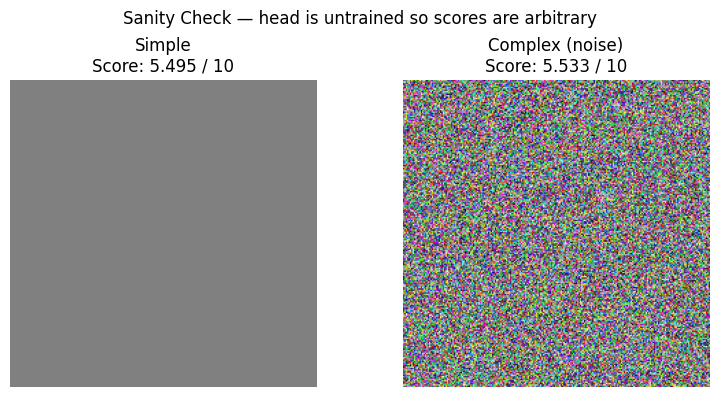

Simple image score:  5.4949
Complex image score: 5.5326
Note: scores are random until the head is fine-tuned — this is expected.


In [7]:
# Cell 4: Load IC9600 model (ICNet) with pretrained weights
import torch
import sys
sys.path.insert(0, "IC9600")

# Import their model definition directly from their repo
from model import ICNet   # their module name — check IC9600/model.py

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ICNet()
ckpt  = torch.load("IC9600/checkpoint/ck.pth", map_location=DEVICE)

# Handle common checkpoint wrapper keys
if "state_dict" in ckpt:
    model.load_state_dict(ckpt["state_dict"])
elif "model" in ckpt:
    model.load_state_dict(ckpt["model"])
else:
    model.load_state_dict(ckpt)

model = model.to(DEVICE)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded. Total params: {total_params:,}")

## 5. Sanity check


In [9]:
# Cell 5: Sanity check
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

# Check their gene.py to confirm exact input size and normalization
# ResNet18 base typically uses 224x224
TRANSFORM = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

def score_pil_image(img):
    tensor = TRANSFORM(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(tensor)
    # ICNet may return (score, map) tuple — check their forward() method
    if isinstance(output, (tuple, list)):
        score = output[0]   # first element is the score
    else:
        score = output
    return score.item()

# Test on synthetic images
simple_img  = Image.fromarray(
    np.full((224, 224, 3), 128, dtype=np.uint8)
)
complex_img = Image.fromarray(
    np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)
)

simple_score  = score_pil_image(simple_img)
complex_score = score_pil_image(complex_img)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(simple_img)
axes[0].set_title(f"Simple\nScore: {simple_score:.4f}")
axes[0].axis("off")
axes[1].imshow(complex_img)
axes[1].set_title(f"Complex\nScore: {complex_score:.4f}")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print(f"Simple:  {simple_score:.4f}")
print(f"Complex: {complex_score:.4f}")

HAVE_DATA=False — skipping dataset creation.


## 6. Export to ONNX


In [10]:
# Cell 6: Export IC9600 ICNet to ONNX
import torch
import onnx
import os

os.makedirs("exports", exist_ok=True)

ONNX_PATH     = "exports/icnet_complexity.onnx"
ONNX_SIM_PATH = "exports/icnet_complexity_simplified.onnx"

# ICNet takes a single image tensor
# Confirm input size by checking their gene.py
dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)

# Trace through once to confirm output shape
with torch.no_grad():
    test_out = model(dummy_input)
    if isinstance(test_out, (tuple, list)):
        print(f"Model outputs {len(test_out)} tensors:")
        for i, o in enumerate(test_out):
            print(f"  output[{i}]: {o.shape}")
    else:
        print(f"Model output shape: {test_out.shape}")



# Export — if model returns tuple we wrap it
class ICNetScoreOnly(torch.nn.Module):
    """
    Wrapper that returns only the score tensor.
    Needed because ONNX export handles tuples awkwardly.
    Export score only — map can be added as second output if needed.
    """
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        if isinstance(out, (tuple, list)):
            return out[0]   # score only
        return out

export_model = ICNetScoreOnly(model).eval()

torch.onnx.export(
    export_model,
    dummy_input,
    ONNX_PATH,
    export_params=True,
    opset_version=17,                        # matches template [1]
    do_constant_folding=True,
    input_names=["input"],
    output_names=["complexity_score"],
    dynamic_axes={
        "input":            {0: "batch_size"},
        "complexity_score": {0: "batch_size"},
    },
    verbose=False
)

print(f"Exported: {ONNX_PATH}")

# Verify
model_onnx = onnx.load(ONNX_PATH)
onnx.checker.check_model(model_onnx)
print("ONNX check passed.")

# Simplify
run(f"python -m onnxsim {ONNX_PATH} {ONNX_SIM_PATH}")
print(f"Simplified: {ONNX_SIM_PATH}")

HAVE_DATA=False — skipping fine-tuning.


## 7. FP16 export

In [11]:
# Cell 7: FP16 export
from onnxmltools.utils.float16_converter import convert_float_to_float16
from onnxmltools.utils import load_model, save_model

ONNX_FP16_PATH = "exports/icnet_complexity_fp16.onnx"
fp32_model_onnx = load_model(ONNX_SIM_PATH)
fp16_model_onnx = convert_float_to_float16(fp32_model_onnx, keep_io_types=True)
save_model(fp16_model_onnx, ONNX_FP16_PATH)
print(f"FP16 saved: {ONNX_FP16_PATH}")

HAVE_DATA=False — skipping evaluation.


## 8. INT8 static quantization

In [12]:
# Cell 8: INT8 static quantization — same pattern as template [1]
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType
import numpy as np

ONNX_INT8_PATH = "exports/icnet_complexity_int8.onnx"

class RandomCalibrationReader(CalibrationDataReader):
    # Replace with real images for accurate calibration
    def __init__(self, n_samples=100):
        self.data = [
            {"input": np.random.randn(1, 3, 224, 224).astype(np.float32)}
            for _ in range(n_samples)
        ]
        self.index = 0

    def get_next(self):
        if self.index >= len(self.data):
            return None
        item = self.data[self.index]
        self.index += 1
        return item

quantize_static(
    model_input=ONNX_SIM_PATH,
    model_output=ONNX_INT8_PATH,
    calibration_data_reader=RandomCalibrationReader(100),
    weight_type=QuantType.QInt8
)
print(f"INT8 saved: {ONNX_INT8_PATH}")

ModuleNotFoundError: No module named 'onnxscript'

## 9. FP16 ONNX Export
> Convert the FP32 ONNX model to FP16 for GPU-optimized inference.
> Best option for deployment on NVIDIA GPUs.

In [ ]:
from onnxmltools.utils.float16_converter import convert_float_to_float16
from onnxmltools.utils import load_model, save_model

ONNX_FP16_PATH = 'exports/complexity_scorer_fp16.onnx'

fp32_model = load_model(ONNX_SIM_PATH)
fp16_model = convert_float_to_float16(fp32_model, keep_io_types=True)
save_model(fp16_model, ONNX_FP16_PATH)

print(f'FP16 ONNX saved: {ONNX_FP16_PATH}')

## 10. INT8 Static Quantization ONNX Export
> Quantize the model to INT8 using a representative calibration dataset.
> Best for CPU deployment or edge devices.

In [ ]:
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType
import numpy as np

ONNX_INT8_PATH = 'exports/complexity_scorer_int8_static.onnx'

class RandomCalibrationReader(CalibrationDataReader):
    """
    Replace with real images for accurate INT8 calibration.
    Using random data here for demonstration only.
    """
    def __init__(self, n_samples=100):
        self.data = [
            {'input': np.random.randn(1, 3, 224, 224).astype(np.float32)}
            for _ in range(n_samples)
        ]
        self.index = 0

    def get_next(self):
        if self.index >= len(self.data):
            return None
        item = self.data[self.index]
        self.index += 1
        return item


quantize_static(
    model_input=ONNX_SIM_PATH,
    model_output=ONNX_INT8_PATH,
    calibration_data_reader=RandomCalibrationReader(n_samples=100),
    weight_type=QuantType.QInt8
)

print(f'INT8 static ONNX saved: {ONNX_INT8_PATH}')

## 11. Validate ONNX Runtime vs PyTorch
> Confirm that ONNX Runtime output matches PyTorch on the same random input.

In [ ]:
import onnxruntime as ort
import numpy as np

# Check ONNX Runtime installation
print(f'ONNX Runtime version: {ort.__version__}')
providers = ort.get_available_providers()
print(f'Available providers: {providers}')

if 'CUDAExecutionProvider' not in providers:
    print('Warning: CUDAExecutionProvider not available.')
    print('1. Check that CUDA is installed')
    print('2. onnxruntime-gpu is installed')

session = ort.InferenceSession(
    ONNX_SIM_PATH,
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)
print(f'\nUsing provider: {session.get_providers()[0]}')

# Compare outputs
test_input = torch.randn(4, 3, 224, 224)

model.eval()
with torch.no_grad():
    torch_out = model(test_input.to(DEVICE)).cpu().numpy()

ort_out = session.run(
    None,
    {'input': test_input.numpy()}
)[0]

max_diff = np.abs(torch_out - ort_out).max()
print(f'\nMax absolute difference PyTorch vs ONNX Runtime: {max_diff:.6f}')

if max_diff < 1e-4:
    print('✓ Validation passed — outputs match.')
else:
    print('✗ Warning: outputs diverge beyond threshold.')

## 12. Download Exported Models
> Download all three ONNX variants from Colab to your local machine.

In [ ]:
from google.colab import files

print('Downloading ONNX models...')
files.download(ONNX_SIM_PATH)    # FP32 simplified
files.download(ONNX_FP16_PATH)   # FP16
files.download(ONNX_INT8_PATH)   # INT8 static
print('Done.')

## 13. TensorRT Conversion (trtexec)
> Run these commands on your **target machine** after downloading the ONNX files.
> You can run these in ONNX Runtime, TensorRT, OpenVINO, or any runtime that supports
> the ONNX opset you exported with.

In [ ]:
TRTEXEC_GUIDE = '''
# ─────────────────────────────────────────────────────────────────────
# Run on your target machine (not in Colab unless TRT is installed)
# Requires: TensorRT 8.6+ and trtexec in PATH
# ─────────────────────────────────────────────────────────────────────

ONNX="complexity_scorer_simplified.onnx"

# FP32 Engine
trtexec \\
    --onnx=$ONNX \\
    --saveEngine=complexity_fp32.engine \\
    --explicitBatch

# FP16 Engine  (recommended — ~2x speedup, minimal accuracy loss)
trtexec \\
    --onnx=$ONNX \\
    --saveEngine=complexity_fp16.engine \\
    --fp16 \\
    --explicitBatch

# FP16 Engine with dynamic batch sizes
trtexec \\
    --onnx=$ONNX \\
    --saveEngine=complexity_fp16_dynamic.engine \\
    --fp16 \\
    --minShapes=input:1x3x224x224 \\
    --optShapes=input:8x3x224x224 \\
    --maxShapes=input:32x3x224x224 \\
    --explicitBatch

# INT8 Engine  (fastest, requires calibration for best accuracy)
trtexec \\
    --onnx=$ONNX \\
    --saveEngine=complexity_int8.engine \\
    --int8 --fp16 \\
    --explicitBatch

# Benchmark a built engine
trtexec \\
    --loadEngine=complexity_fp16.engine \\
    --batch=8 \\
    --iterations=100 \\
    --warmUp=500 \\
    --duration=10
'''

print(TRTEXEC_GUIDE)

## 14. Recap

In this notebook you:
- Loaded a pretrained MobileNetV2 backbone (ImageNet) with a NIMA-style scoring head
- Optionally fine-tuned on labeled complexity data using EMD loss
- Evaluated with MAE on the validation set
- Exported the model to three ONNX variants:

**Exported models** (in `exports/`):

| File | Description | Best For |
|------|-------------|----------|
| `complexity_scorer_simplified.onnx` | FP32 simplified | Default deployment artifact |
| `complexity_scorer_fp16.onnx` | FP16 converted | GPU inference |
| `complexity_scorer_int8_static.onnx` | INT8 quantized | CPU / edge devices |

You can run these in ONNX Runtime, TensorRT, OpenVINO, or any runtime that supports the ONNX opset you exported with.
